## Introducción

Tras realizar los análisis del challenge anterior, Telecom X LATAM me promovió a integrante del equipo de Data Science, y me asignó la nueva misión de diseñar modelos predictivos que predigan qué clientes tienen mayor probabilidad de abandonar el servicio, a los fines de anticiparnos (la empresa) a las cancelaciones que realicen los clientes. Para esto, desarrollaré dos modelos de machine learning destinados a analizar las causas potenciales del abandono masivo del servicio.

# Preparación de los datos

Para poder trabajar con los datos iniciales, es necesario ir a la carpeta de Archivos (al costado), arrastrar el CSV allí (debajo de sample_data, es decir, a la altura de dicha carpeta, sin entrar a la misma), y ejecutar el código.

Estoy siguiendo una práctica común en lenguajes como Python, consistente en importar todo al principio del programa.

In [ ]:
# Importación de librerías que no son de Sci-Kit Learn
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de librerías de Sci-Kit Learn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ignoramos las advertencias que vaya a dar el servidor de Colab
warnings.filterwarnings('ignore')

# Importación del DataFrame; la variable se llamará X porque la usaremos en el cálculo estadístico
X = pd.read_csv('/content/datos_tratados.csv')
X.head()

,ID,Cancelación (churn),Género,Jubilado (+60 años),Con pareja,Dependientes,Antigüedad (meses),Servicio telefónico,Servicio de internet,Seguridad en línea,...,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming de películas,Tipo de contrato,Factura electrónica,Método de pago,Cuentas mensuales,Cobro total,Cuentas diarias
0,0002-ORFBO,False,Femenino,False,True,True,9,Una línea,DSL,False,...,False,True,True,False,Un año,True,Cheque enviado por correo,65.6,593.30,2.19
1,0003-MKNFE,False,Masculino,False,False,False,9,Múltiples líneas,DSL,False,...,False,False,False,True,Mes a mes,False,Cheque enviado por correo,59.9,542.40,2.00
2,0004-TLHLJ,True,Masculino,False,False,False,4,Una línea,Fibra óptica,False,...,True,False,False,False,Mes a mes,True,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,True,Masculino,True,True,False,13,Una línea,Fibra óptica,False,...,True,False,True,True,Mes a mes,True,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,True,Femenino,True,True,False,3,Una línea,Fibra óptica,False,...,False,True,True,False,Mes a mes,True,Cheque enviado por correo,83.9,267.40,2.80


## Eliminación de columnas irrelevantes (primera etapa)

En principio, eliminaremos las columnas de ID y de cuentas diarias, cada una por sus correspondientes razones:

1. Los IDs de cada cliente son únicos, y un (identidicador para una fila de una base de datos) no cumple ningún rol en un análisis estadístico.
2. La columna de Cuentas diarias se calculó en el challenge anterior, dividiendo los valores de Cuentas mensuales en 30, y redondeando a dos cifras. Es una columna redundante, cuyo valor es una operación matemática (invertible) aplicada a otra columna, y por lo tanto no tiene ningún interés.

In [ ]:
X.drop(columns = ['ID', 'Cuentas diarias'], inplace = True)
X.head()

,Cancelación (churn),Género,Jubilado (+60 años),Con pareja,Dependientes,Antigüedad (meses),Servicio telefónico,Servicio de internet,Seguridad en línea,Copia de seguridad en línea,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming de películas,Tipo de contrato,Factura electrónica,Método de pago,Cuentas mensuales,Cobro total
0,False,Femenino,False,True,True,9,Una línea,DSL,False,True,False,True,True,False,Un año,True,Cheque enviado por correo,65.6,593.30
1,False,Masculino,False,False,False,9,Múltiples líneas,DSL,False,False,False,False,False,True,Mes a mes,False,Cheque enviado por correo,59.9,542.40
2,True,Masculino,False,False,False,4,Una línea,Fibra óptica,False,False,True,False,False,False,Mes a mes,True,Cheque electrónico,73.9,280.85
3,True,Masculino,True,True,False,13,Una línea,Fibra óptica,False,True,True,False,True,True,Mes a mes,True,Cheque electrónico,98.0,1237.85
4,True,Femenino,True,True,False,3,Una línea,Fibra óptica,False,False,False,True,True,False,Mes a mes,True,Cheque enviado por correo,83.9,267.40


Ahora veremos los tipos de datos de las columnas. Véase que las columnas de strings están instanciadas como 'object' por la importación. No me molestaré en convertirlas a strings, por simplicidad y porque directamente las convertiré en numéricas más adelante.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Cancelación (churn)          7043 non-null   bool   
 1   Género                       7043 non-null   object 
 2   Jubilado (+60 años)          7043 non-null   bool   
 3   Con pareja                   7043 non-null   bool   
 4   Dependientes                 7043 non-null   bool   
 5   Antigüedad (meses)           7043 non-null   int64  
 6   Servicio telefónico          7043 non-null   object 
 7   Servicio de internet         7043 non-null   object 
 8   Seguridad en línea           7043 non-null   bool   
 9   Copia de seguridad en línea  7043 non-null   bool   
 10  Protección de dispositivos   7043 non-null   bool   
 11  Soporte técnico              7043 non-null   bool   
 12  Streaming TV                 7043 non-null   bool   
 13  Streaming de pelíc

In [ ]:
# Valores únicos de las columnas del DataFrame
def imprimir():
  for nombre_columna in X.columns.values.tolist():
    print(f"{nombre_columna}: {X[nombre_columna].unique()}")

imprimir()

Cancelación (churn): [False  True]
Género: ['Femenino' 'Masculino']
Jubilado (+60 años): [False  True]
Con pareja: [ True False]
Dependientes: [ True False]
Antigüedad (meses): [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
Servicio telefónico: ['Una línea' 'Múltiples líneas' 'No']
Servicio de internet: ['DSL' 'Fibra óptica' 'No']
Seguridad en línea: [False  True]
Copia de seguridad en línea: [ True False]
Protección de dispositivos: [False  True]
Soporte técnico: [ True False]
Streaming TV: [ True False]
Streaming de películas: [False  True]
Tipo de contrato: ['Un año' 'Mes a mes' 'Dos años']
Factura electrónica: [ True False]
Método de pago: ['Cheque enviado por correo' 'Cheque electrónico'
 'Tarjeta de crédito (automático)' 'Transferencia bancaria (automático)']
Cuentas mensuales: [65.6  59.9  73.9  ... 91.75

Véase que las columnas de 'object' (strings) tienen unos pocos valores únicos; recuerde que tales columnas son las de género, servicio telefónico y de internet, tipo de contrato, y método de pago. En el DataFrame se consideran, por ejemplo, sólo los géneros masculino y femenino.

Antes de normalizar el DataFrame X, comentaré un detalle particularmente interesante con respecto a una de las columnas del mismo. La columna de Cobro total se encuentra explicada, casi en su totalidad, por los valores de las columnas de la antigüedad y las cuentas mensuales. La relación entre estas variables es:

$$ \text{Cobro total} \approx \text{Cuotas mensuales} * \text{Antigüedad} $$

Los casos en los que la igualdad no se cumple o el valor del producto tiene una diferencia algo pronunciada con el cobro total, se deben a que el cliente está pagando por servicios caros como fibra óptica (el servicio más caro) o múltiples líneas telefónicas. Por eso, como luego veremos, la correlación entre esta columna y la de la antigüedad del cliente es elevadísima. Deberíamos eliminar dicha columna, aunque lo haremos luego de haber explorado a fondo esta correlación. Primeramente, veremos brevemente la diferencia entre el cobro total y el producto entre el cobro mensual y la antigüedad en meses.

In [ ]:
diferencias_costos = X['Cobro total'] - (X['Cuentas mensuales'] * X['Antigüedad (meses)'])
diferencias_costos

,0
0,2.90
1,3.30
2,-14.75
3,-36.15
4,15.70
...,...
7038,25.95
7039,1.50
7040,-7.85
7041,81.70


In [ ]:
print(f'La diferencia máxima es {diferencias_costos.max()} y la mínima es {diferencias_costos.min()}')

La diferencia máxima es 373.2500000000009 y la mínima es -370.84999999999945


In [ ]:
# Ahora lo hacemos considerando los valores absolutos de dichas diferencias, ignorando el signo
diferencias_costos = diferencias_costos.abs()
print(f'La diferencia absoluta máxima es {diferencias_costos.max()} y la mínima es {diferencias_costos.min()}')

La diferencia absoluta máxima es 373.2500000000009 y la mínima es 0.0


In [ ]:
# Aquí se puede ver que, en 625 columnas, la igualdad exacta se cumplió.
diferencias_costos[diferencias_costos == 0.0]

,0
17,0.0
19,0.0
25,0.0
48,0.0
63,0.0
...,...
6980,0.0
7007,0.0
7021,0.0
7033,0.0


## Encoding y estandarización

Es necesario transformar las columnas, en este punto, a formato numérico para su tratamiento con Machine Learning. Para esto, se usará el famoso One-Hot Encoding.

También será necesario aplicar estandarización; esto debido a que filas como las Cuentas mensuales presentaban una gran desviación y cantidad de outliers, así como valores mucho mayores que 0 o 1 (los únicos valores de la mayoría de las columnas del DataFrame), lo cual afectará el análisis. La estandarización es una herramienta muy eficaz para manejar la gran desviación de las columnas numéricas no-binarias.

La fórmula que ejecutará el pipeline es:

$$z = \frac{x - \mu}{\sigma}$$

Esto convertirá las columnas de antigüedad y cobro mensual en columnas de valores oscilantes entre -3 y 3, centrados en 0.

### Transformación

Aplicamos los procesos de preprocesamiento y de estandarización

In [ ]:
# Transformar columnas de booleanos a enteros (esta conversión es explícita: convierte los False en 0 y True en 1)
columnas_bool = X.select_dtypes(include=['bool']).columns
X[columnas_bool] = X[columnas_bool].astype(int)

# Convertir la columna 'Género' en 'Género masculino', que indica si un cliente es masculino (1) o femenino (0)
X.rename(columns={'Género': 'Género masculino'}, inplace=True)
X['Género masculino'] = X['Género masculino'].map({'Masculino': 1, 'Femenino': 0}).astype(int)

# Definir las columnas de objects/strings todavía pendientes de transformar, que queremos tratar
columnas_strings = ['Servicio telefónico', 'Servicio de internet', 'Tipo de contrato', 'Método de pago']

# Pasar una lista al parámetro 'drop' para elegir qué categoría eliminar de cada fila de strings (instanciados como objetos).
categorias_a_eliminar = [
    'No', # Sin servicio telefónico
    'No', # Sin servicio de internet
    'Mes a mes', # Tipo de contrato
    'Cheque enviado por correo' # Método de pago
]

# Definir las columnas numéricas no-binarias a las que se aplicará la estandarización
columnas_escalar = ['Antigüedad (meses)', 'Cuentas mensuales', 'Cobro total']

# Crear el transformador y hacer que devuelva un DataFrame de Pandas como output
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop=categorias_a_eliminar, handle_unknown='ignore', sparse_output=False), columnas_strings),
        ('num', StandardScaler(), columnas_escalar) # Estandarización para las columnas de columnas_escalar
    ],
    remainder='passthrough' # Mantiene el resto de las columnas (las ya numéricas)
)
preprocessor.set_output(transform="pandas")

# Ejecutar la transformación
X = preprocessor.fit_transform(X)

# Imprimir las primeras 5 filas del nuevo DataFrame, véase que las columnas de 'object' ahora son números de
# 0 a 1
X.head()

,cat__Servicio telefónico_Múltiples líneas,cat__Servicio telefónico_Una línea,cat__Servicio de internet_DSL,cat__Servicio de internet_Fibra óptica,cat__Tipo de contrato_Dos años,cat__Tipo de contrato_Un año,cat__Método de pago_Cheque electrónico,cat__Método de pago_Tarjeta de crédito (automático),cat__Método de pago_Transferencia bancaria (automático),num__Antigüedad (meses),...,remainder__Jubilado (+60 años),remainder__Con pareja,remainder__Dependientes,remainder__Seguridad en línea,remainder__Copia de seguridad en línea,remainder__Protección de dispositivos,remainder__Soporte técnico,remainder__Streaming TV,remainder__Streaming de películas,remainder__Factura electrónica
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.951682,...,0,1,1,0,1,0,1,1,0,1
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.951682,...,0,0,0,0,0,0,0,0,1,0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.155283,...,0,0,0,0,0,1,0,0,0,1
3,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.788800,...,1,1,0,0,1,1,0,1,1,1
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.196004,...,1,1,0,0,0,0,1,1,0,1


Observaremos los tipos de dato de las columnas del actual DataFrame; los tipos de dato ahora son puramente numéricos.

Véase que me cambió el orden de las columnas y me quedaron con nombres horribles (primeras 9 columnas) o que comienzan con 'num__' o 'remainder__' (el resto de las filas). Y respecto a las primeras 9 columnas, son columnas de floats, y no de enteros, como se desearía, si bien sus valores sí son 0 o 1.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   cat__Servicio telefónico_Múltiples líneas                7043 non-null   float64
 1   cat__Servicio telefónico_Una línea                       7043 non-null   float64
 2   cat__Servicio de internet_DSL                            7043 non-null   float64
 3   cat__Servicio de internet_Fibra óptica                   7043 non-null   float64
 4   cat__Tipo de contrato_Dos años                           7043 non-null   float64
 5   cat__Tipo de contrato_Un año                             7043 non-null   float64
 6   cat__Método de pago_Cheque electrónico                   7043 non-null   float64
 7   cat__Método de pago_Tarjeta de crédito (automático)      7043 non-null   float64
 8   cat__Método de pago_Transfer

Revisamos de nuevo los valores únicos de las columnas, para verificar que las primeras sólo admiten 0.0 y 1.0 como valores

In [ ]:
imprimir()

cat__Servicio telefónico_Múltiples líneas: [0. 1.]
cat__Servicio telefónico_Una línea: [1. 0.]
cat__Servicio de internet_DSL: [1. 0.]
cat__Servicio de internet_Fibra óptica: [0. 1.]
cat__Tipo de contrato_Dos años: [0. 1.]
cat__Tipo de contrato_Un año: [1. 0.]
cat__Método de pago_Cheque electrónico: [0. 1.]
cat__Método de pago_Tarjeta de crédito (automático): [0. 1.]
cat__Método de pago_Transferencia bancaria (automático): [0. 1.]
num__Antigüedad (meses): [-0.95168167 -1.15528349 -0.78880022 -1.19600386  1.57298088  1.24721797
 -1.0331224   1.32865869  0.88073469  1.61370124 -1.11456313  0.96217542
  0.06632742 -1.27744458  0.51425142  0.71785324 -0.38159658  0.92145506
 -0.25943549  1.49154015  0.18848851  0.67713287  1.36937906  1.41009942
 -0.50375767  0.43281069  1.08433651 -0.82952058 -0.21871513 -1.23672422
 -0.30015585 -0.1372744  -0.74807986  0.10704778  1.28793833  0.26992924
  0.3106496  -0.87024095 -1.07384277 -0.09655404  1.53226051  1.00289578
  1.04361615 -0.66663913 -0.01

### Renombramiento de columnas

Renombramos las columnas del DataFrame, dado que quedaron con nombres repugnantes (innecesariamente largos, difíciles de leer y entender, y con un formato extraño y bastante feo, como 'remainder__Columna vieja conservada' o 'cat__Columna vieja eliminada__Categoría') como consecuencia del encoding previo

In [ ]:
# Convertimos las columnas generadas por el encoder (que empiezan con 'cat__') de float a int
columnas_cat = [col for col in X.columns if col.startswith('cat__')]
X[columnas_cat] = X[columnas_cat].astype(int)

# Retiramos el 'num__' y el 'remainder__' de las últimas filas
X.columns = X.columns.str.replace('num__', '', regex=False)
X.columns = X.columns.str.replace('remainder__', '', regex=False)

# Renombramos manualmente las primeras filas
X.rename(columns = {
    'cat__Servicio telefónico_Múltiples líneas': 'Múltiples líneas',
    'cat__Servicio telefónico_Una línea': 'Única línea',
    'cat__Servicio de internet_DSL': 'Tiene DSL',
    'cat__Servicio de internet_Fibra óptica': 'Tiene fibra óptica',
    'cat__Tipo de contrato_Dos años': 'Contrato por dos años',
    'cat__Tipo de contrato_Un año': 'Contrato por un año',
    'cat__Método de pago_Cheque electrónico': 'Pago por cheque electrónico',
    'cat__Método de pago_Tarjeta de crédito (automático)': 'Pago por tarjeta de crédito (automático)',
    'cat__Método de pago_Transferencia bancaria (automático)': 'Pago por transferencia bancaria (automático)'
}, inplace = True)

# Vemos de nuevo los nombres de las columnas, cómo estan ordenados, y los valores únicos de las mismas. Verificamos que las
# primeras 9 columnas tienen valores enteros, siendo 0 o 1 sólamente. Pero el orden de las columnas no es el más intuitivo.
imprimir()

Múltiples líneas: [0 1]
Única línea: [1 0]
Tiene DSL: [1 0]
Tiene fibra óptica: [0 1]
Contrato por dos años: [0 1]
Contrato por un año: [1 0]
Pago por cheque electrónico: [0 1]
Pago por tarjeta de crédito (automático): [0 1]
Pago por transferencia bancaria (automático): [0 1]
Antigüedad (meses): [-0.95168167 -1.15528349 -0.78880022 -1.19600386  1.57298088  1.24721797
 -1.0331224   1.32865869  0.88073469  1.61370124 -1.11456313  0.96217542
  0.06632742 -1.27744458  0.51425142  0.71785324 -0.38159658  0.92145506
 -0.25943549  1.49154015  0.18848851  0.67713287  1.36937906  1.41009942
 -0.50375767  0.43281069  1.08433651 -0.82952058 -0.21871513 -1.23672422
 -0.30015585 -0.1372744  -0.74807986  0.10704778  1.28793833  0.26992924
  0.3106496  -0.87024095 -1.07384277 -0.09655404  1.53226051  1.00289578
  1.04361615 -0.66663913 -0.01511331  0.02560706 -0.91096131 -0.46303731
  1.16577724 -0.70735949  0.47353106 -0.42231695 -0.34087622 -0.54447804
  0.59569215  1.2064976   0.55497178  0.799293

### Reordenamiento

Reordenamos las columnas del DataFrame, dado que el encoding previo, además de alterar severamente los nombres de las columnas, cambió también el orden de las mismas.

In [ ]:
# Reordenamos las columnas de forma intuitiva y similar al DataFrame viejo
X = X[[
    # Demografía (información personal del cliente)
    'Género masculino', 'Jubilado (+60 años)', 'Con pareja', 'Dependientes',
    # Tiempo
    'Antigüedad (meses)',
    # Servicios (One-Hot + Booleanos)
    'Única línea', 'Múltiples líneas',
    'Tiene DSL', 'Tiene fibra óptica',
    'Seguridad en línea', 'Copia de seguridad en línea', 'Protección de dispositivos',
    'Soporte técnico', 'Streaming TV', 'Streaming de películas',
    # Contrato
    'Contrato por un año', 'Contrato por dos años',
    # Facturación
    'Factura electrónica',
    # Tipos de pago
    'Pago por cheque electrónico', 'Pago por tarjeta de crédito (automático)',
    'Pago por transferencia bancaria (automático)',
    # Cobro de Telecom X
    'Cuentas mensuales', 'Cobro total',
    # El resultado final (Target)
    'Cancelación (churn)'
]]

# Verificamos que todo esté en su sitio
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Género masculino                              7043 non-null   int64  
 1   Jubilado (+60 años)                           7043 non-null   int64  
 2   Con pareja                                    7043 non-null   int64  
 3   Dependientes                                  7043 non-null   int64  
 4   Antigüedad (meses)                            7043 non-null   float64
 5   Única línea                                   7043 non-null   int64  
 6   Múltiples líneas                              7043 non-null   int64  
 7   Tiene DSL                                     7043 non-null   int64  
 8   Tiene fibra óptica                            7043 non-null   int64  
 9   Seguridad en línea                            7043 non-null   i

## Proporción de cancelaciones

Calculamos las cantidades y porcentajes de clientes que cancelaron y que no lo hicieron

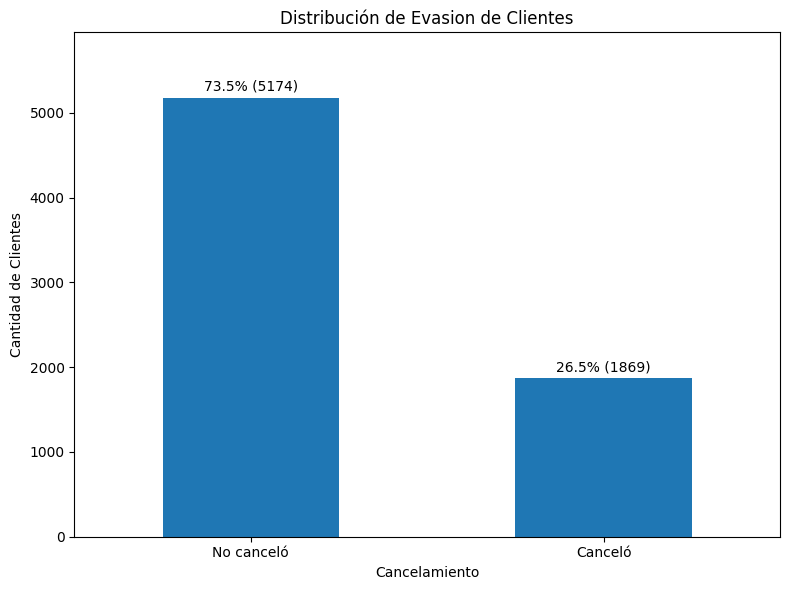

El ratio de desbalance es la cantidad de clientes que cancelaron dividido la cantidad de clientes que no.
 El ratio de desbalance es: 0.36122922303826827


In [ ]:
# Mismo cálculo de distribución de evasión que en el challenge anterior
vector_cancelacion = X['Cancelación (churn)'].map({
    1: 'Canceló',
    0: 'No canceló'
}).astype('string')
plt.figure(figsize=(8, 6))

ax = vector_cancelacion.value_counts().plot(kind='bar')
plt.title('Distribución de Evasion de Clientes')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)

plt.ylim(0, vector_cancelacion.value_counts().max() * 1.15)

for i, percentage in enumerate((vector_cancelacion.value_counts() / len(vector_cancelacion)) * 100):
    ax.text(i, vector_cancelacion.value_counts().iloc[i] + 50, f'{percentage:.1f}% ({vector_cancelacion.value_counts().iloc[i]})', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Ratio de desbalance: Clientes que cancelaron / Clientes que se quedaron
print('El ratio de desbalance es la cantidad de clientes que cancelaron dividido la cantidad de clientes que no.\n',
   'El ratio de desbalance es:', vector_cancelacion.value_counts().iloc[1] / vector_cancelacion.value_counts().iloc[0])

# Correlación y selección de variables y segunda eliminación de variables innecesarias

## Análisis de la matriz de correlación

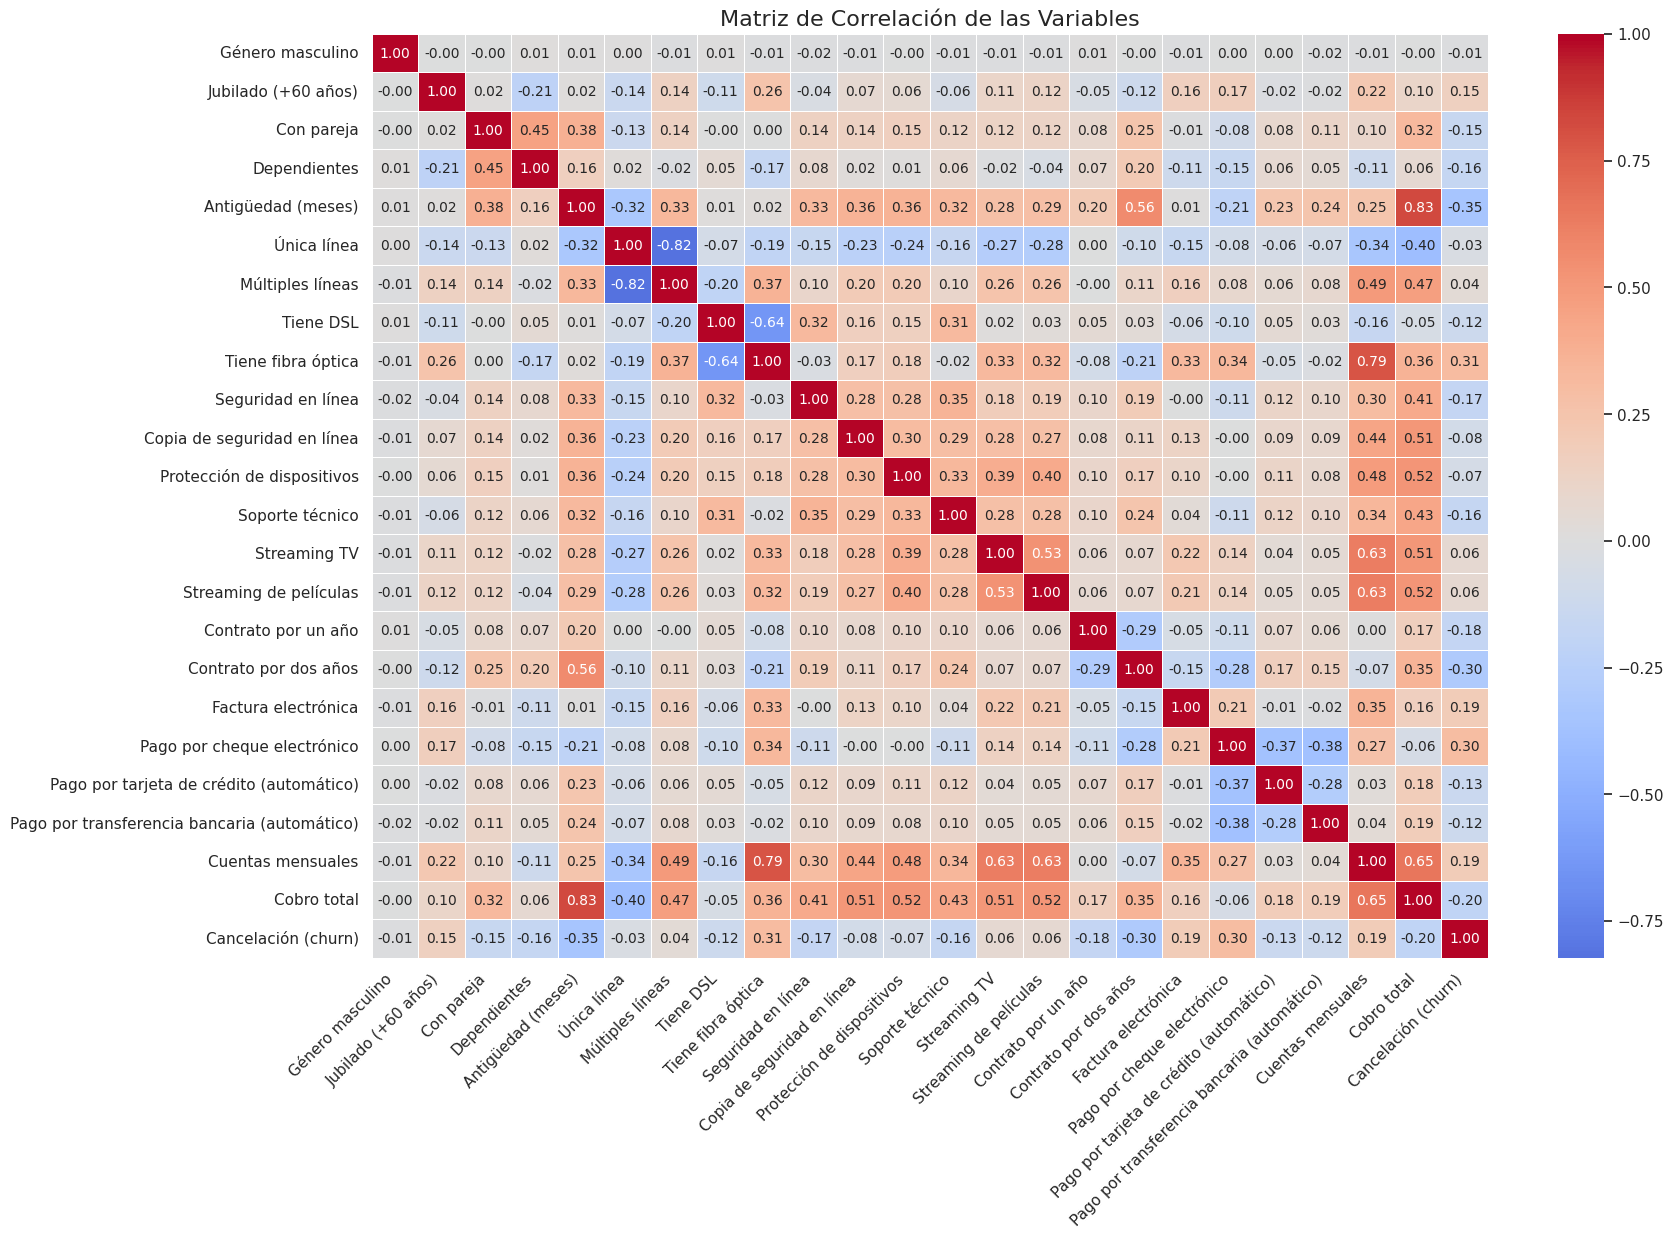

Correlación con la Cancelación (churn):
Cancelación (churn)                             1.000000
Tiene fibra óptica                              0.308020
Pago por cheque electrónico                     0.301919
Cuentas mensuales                               0.193356
Factura electrónica                             0.191825
Jubilado (+60 años)                             0.150889
Streaming TV                                    0.063228
Streaming de películas                          0.061382
Múltiples líneas                                0.040102
Género masculino                               -0.008612
Única línea                                    -0.032569
Protección de dispositivos                     -0.066160
Copia de seguridad en línea                    -0.082255
Pago por transferencia bancaria (automático)   -0.117937
Tiene DSL                                      -0.124214
Pago por tarjeta de crédito (automático)       -0.134302
Con pareja                                     -

In [ ]:
# Función para calcular la matriz de correlación de un DataFrame
def datos_correlacion(un_dataframe):
    # Ajustamos el estilo para que se vea mejor
    sns.set_theme(style='white')

    # Calculamos la matriz de correlación
    corr_matrix = un_dataframe.corr()

    # Configuramos un tamaño de figura más grande para que no se vea amontonado
    plt.figure(figsize=(18, 12))

    # Creamos el mapa de calor con ajustes visuales mejorados
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        annot_kws={'size': 10} # Tamaño de la fuente de los números
    )

    plt.title('Matriz de Correlación de las Variables', fontsize=16)
    plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas del eje X
    plt.show()

    # Mostramos las correlaciones específicas con la variable objetivo
    print('Correlación con la Cancelación (churn):')
    print(corr_matrix['Cancelación (churn)'].sort_values(ascending=False))

datos_correlacion(X)

Véase que las cuentas totales tienen una fuerte correlación (0.64) con las cuentas mensuales, y una aún mayor con la antigüedad (0.83). Si bien 0.64 no es una correlación demasiado preocupante entre las cuentas mensuales y totales, es porque gran parte de esta doble correlación está explicada por la antigüedad del cliente. Esto es una bandera roja: las cuentas totales podrían ser una variable inútil o redundante. Eliminar esta columna parece una muy buena idea.

Es más: La columna de Cobro total se encuentra explicada, casi en su totalidad, por los valores de las columnas de la antigüedad y las cuentas mensuales. La relación entre estas variables es:

$$ \text{Cobro total} \approx \text{Cuotas mensuales} * \text{Antigüedad} $$

Los casos en los que la igualdad no se cumple o el valor del producto tiene una diferencia algo pronunciada con el cobro total, se deben a que el cliente está pagando por servicios caros como fibra óptica o múltiples líneas telefónicas. Por lo tanto, sí deberíamos eliminar los cobros totales.

Además, puede evidenciarse que el género no tiene ninguna relevancia en las cancelaciones ni tiene casi correlación con ninguna otra variable; sólo molesta. Así que también es descartable.

Respecto al servicio telefónico, hay una correlación negativa muy fuerte (-0.82) entre los casos en los que se cuenta con múltiples líneas, y en los que se cuenta con una sola; esto debido a que, como se vio en el challenge anterior, la cantidad de clientes que no contaban con ninguna línea es mínima. Por lo tanto, lo conveniente aquí es eliminar la categoría de menor peso: la columna de 'Una línea'. De este modo, el modelo interpretará que o bien un cliente tiene un servicio telefónico 'premium' o de costo elevado (múltiples líneas) o bien un servicio más regular (una única línea o ninguna).

Ahora bien, hay otros dos temas que nos interesan fuertemente:
1. Hay una correlación negativa pronunciada (-0.64) entre la tenencia de DSL o de fibra óptica entre los clientes. Si uno de los dos tiene DSL, lógicamente no tendrá fibra, ni viceversa. La correlación no es demasiado alta como en el caso de las cantidades de líneas telefónicas porque hay muchos más clientes sin servicio de internet. Si bien la correlación no es demasiado alta o alarmante, hay alguna redundancia entre las filas.
2. Lo importante: Hay una correlación de 0.79 entre las cuentas mensuales y la tenencia de fibra óptica. La fibra es el producto más caro de Telecom X, por lo que tenerla es un sinónimo de pagar mucho. Dejar ambas filas supone un **problema de multicolinealidad**: si dejamos ambas filas, el modelo se confundirá, y no va a saber si los clientes se van porque la fibra anda mal o porque la cuenta es demasiado elevada.
La solución que aplicaré a este problema es eliminar ambas columnas, 'Tiene DSL' y 'Tiene fibra óptica'. La columna de DSL no aporta un gran valor, podría omitirse y dejar que el modelo note que, si el cliente no tiene fibra, entonces tiene DSL o no tiene internet, por lo que cuenta con un servicio más barato. Y la columna de fibra óptica se correlaciona muy fuertemente con los gastos mensuales, por lo que también podría omitirse para dejar solamente los gastos mensuales: el modelo, entonces, deducirá que si el cliente tiene gastos elevados, entonces tiene seguramente fibra, y de otro modo, tiene DSL o no cuenta con internet (plan más barato).

## Eliminación de columnas problemáticas

In [ ]:
X.drop(columns = ['Cobro total', 'Género masculino', 'Única línea', 'Tiene DSL', 'Tiene fibra óptica'], inplace = True)
X.head()

,Jubilado (+60 años),Con pareja,Dependientes,Antigüedad (meses),Múltiples líneas,Seguridad en línea,Copia de seguridad en línea,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming de películas,Contrato por un año,Contrato por dos años,Factura electrónica,Pago por cheque electrónico,Pago por tarjeta de crédito (automático),Pago por transferencia bancaria (automático),Cuentas mensuales,Cancelación (churn)
0,0,1,1,-0.951682,0,0,1,0,1,1,0,1,0,1,0,0,0,0.027862,0
1,0,0,0,-0.951682,1,0,0,0,0,0,1,0,0,0,0,0,0,-0.161583,0
2,0,0,0,-1.155283,0,0,0,1,0,0,0,0,0,1,1,0,0,0.303720,1
3,1,1,0,-0.788800,0,0,1,1,0,1,1,0,0,1,1,0,0,1.104706,1
4,1,1,0,-1.196004,0,0,0,0,1,1,0,0,0,1,0,0,0,0.636080,1


## Repetición del análisis de correlación

El mismo análisis de correlación previamente hecho se repetirá ahora, en el contexto actual, sin las columnas previamente eliminadas. Véase que las correlaciones entre variables distintas (ya sean binarias o no) ya no son tan elevadas o reducidas (cercanas a 1 o -1).

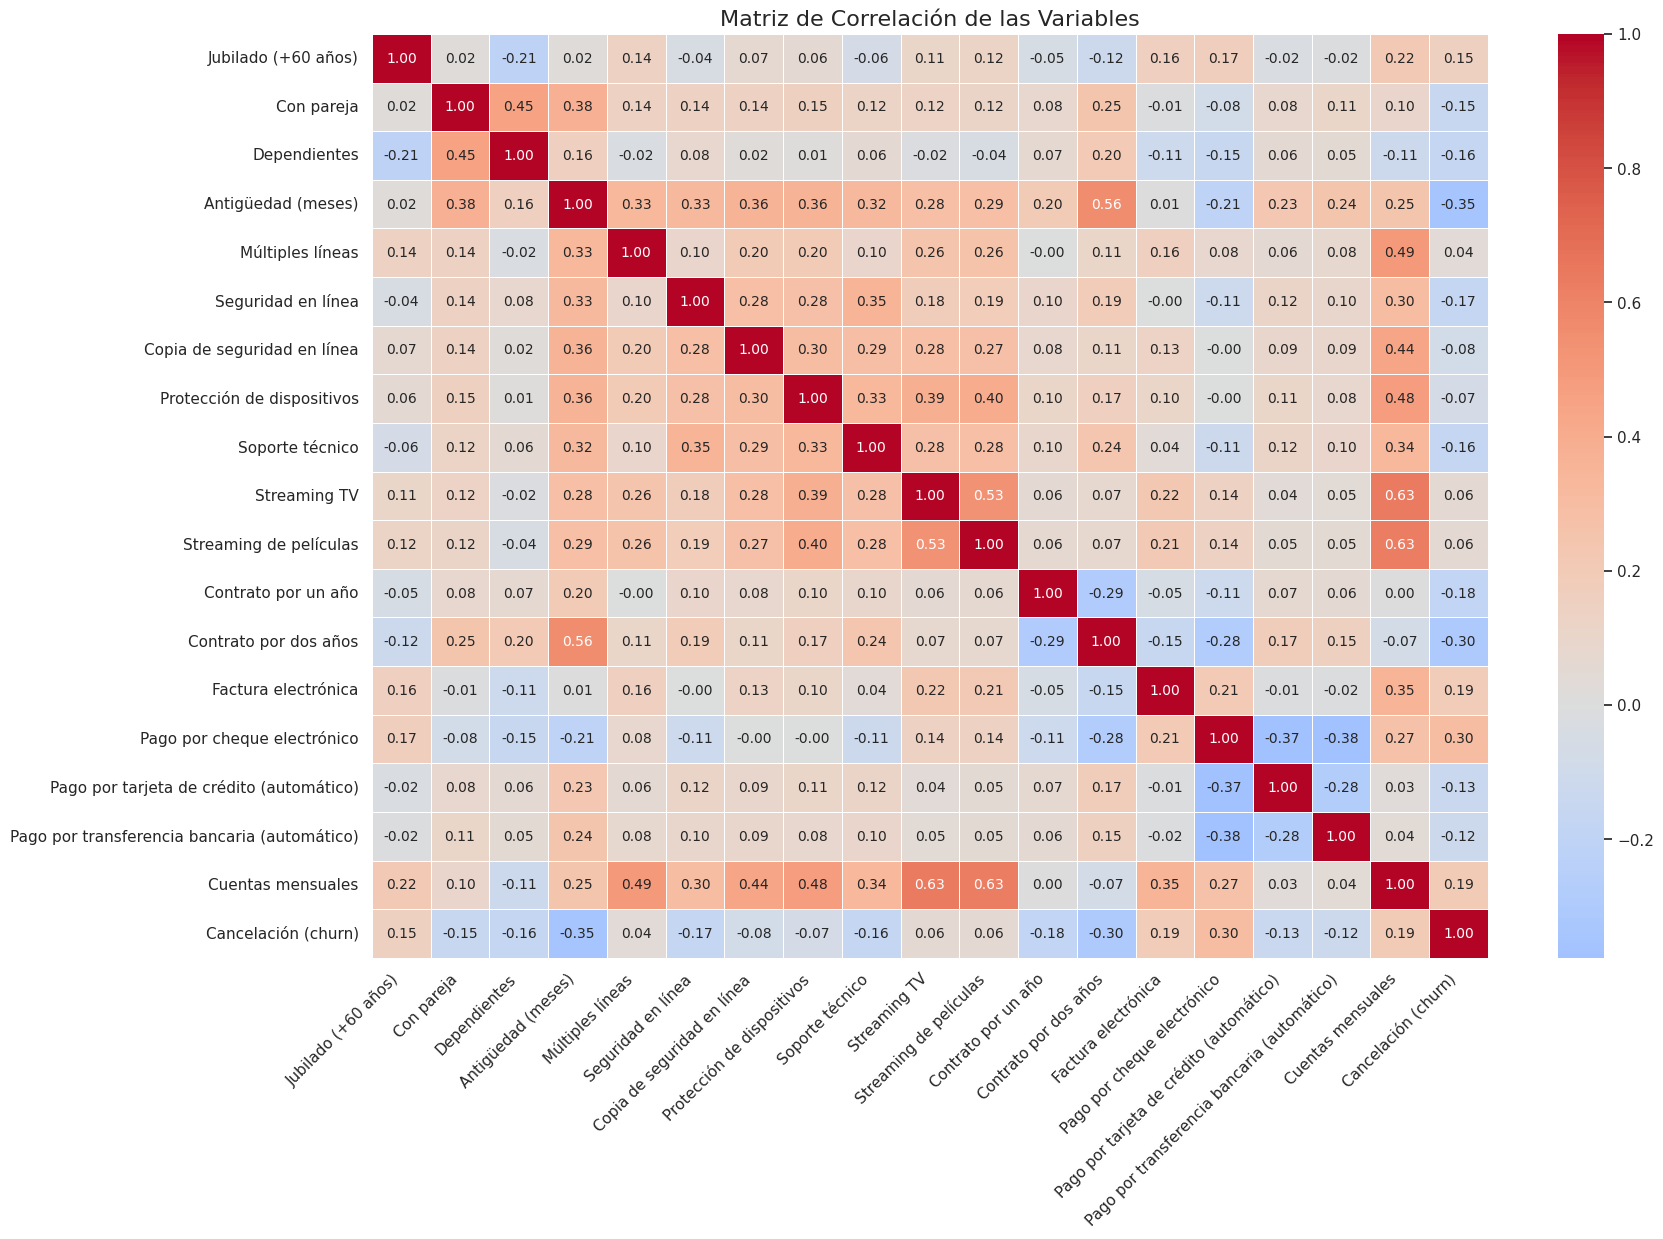

Correlación con la Cancelación (churn):
Cancelación (churn)                             1.000000
Pago por cheque electrónico                     0.301919
Cuentas mensuales                               0.193356
Factura electrónica                             0.191825
Jubilado (+60 años)                             0.150889
Streaming TV                                    0.063228
Streaming de películas                          0.061382
Múltiples líneas                                0.040102
Protección de dispositivos                     -0.066160
Copia de seguridad en línea                    -0.082255
Pago por transferencia bancaria (automático)   -0.117937
Pago por tarjeta de crédito (automático)       -0.134302
Con pareja                                     -0.150448
Dependientes                                   -0.164221
Soporte técnico                                -0.164674
Seguridad en línea                             -0.171226
Contrato por un año                            -

In [ ]:
datos_correlacion(X)

## Análisis dirigido

Aquí observamos la relación de la cancelación del servicio con variables como el tiempo de contrato, el gasto total o los servicios elegidos, usando boxplots o diagramas de dispersión.

### Boxplots

Puede evidenciarse que los clientes que cancelan tienen una mediana de cobros mensuales mucho más alta que los que no, evidenciando que el costo elevado puede ser un factor influyente en la fuga de clientes.

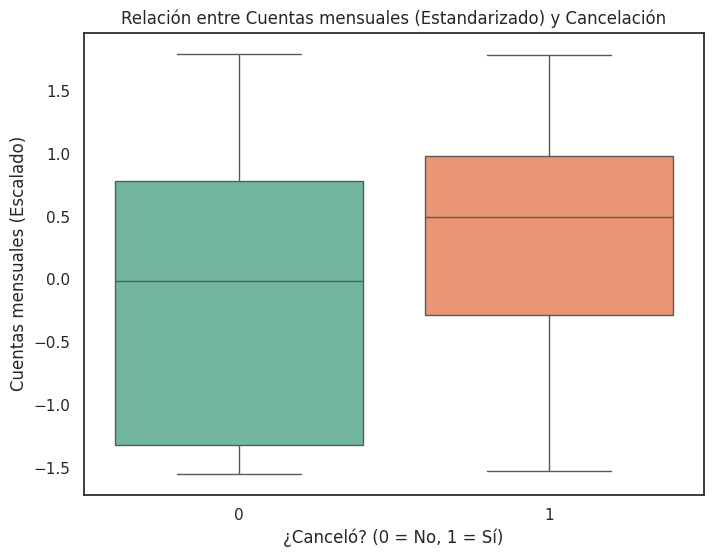

In [ ]:
def boxplot_estandarizado(columna_floats):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cancelación (churn)', y=columna_floats, data=X, palette='Set2')
    plt.title(f'Relación entre {columna_floats} (Estandarizado) y Cancelación')
    plt.xlabel('¿Canceló? (0 = No, 1 = Sí)')
    plt.ylabel(f'{columna_floats} (Escalado)')
    plt.show()

boxplot_estandarizado('Cuentas mensuales')

Hay una relación inversa clara entre la antigüedad y la cancelación: la mayor cantidad de clientes que cancelan tienen una antigüedad mínima. Esto refleja que el riesgo de abandono es mucho mayor y muy crítico en los primeros meses de servicio.

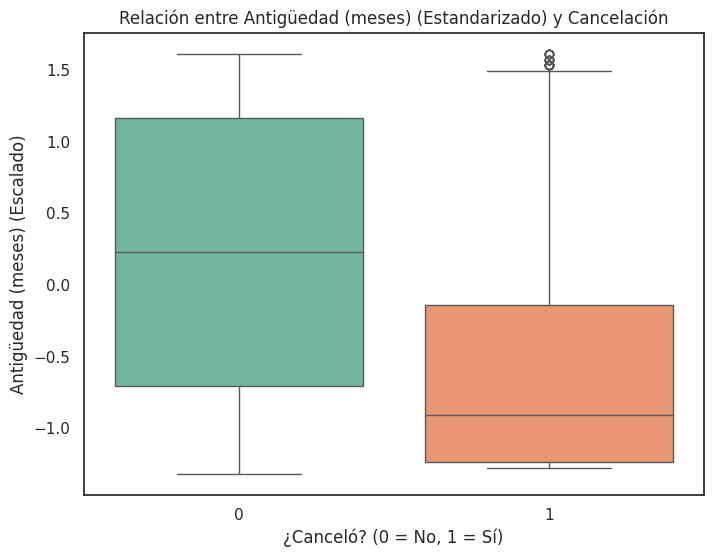

In [ ]:
boxplot_estandarizado('Antigüedad (meses)')

### Diagramas de dispersión (scatter plots)

Existe una clara concentración de cancelaciones (puntos rojos) en el rincón superior izquierdo, es decir, clientes nuevos que pagan cuotas mensuales elevadas. Estos clientes podrían estar probando el servicio y optando por los planes más costosos (fibra óptica, múltiples servicios de internet, múltiples líneas telefónicas, etc.) y abandonándolo porque sus expectativas no se cumplieron.

Y en general, los clientes más viejos tienden a continuar con el servicio (puntos principalmente azules), independientemente de sus cuentas mensuales, aunque la mayor concentración de puntos azules está entre los que pagan poco por mes.

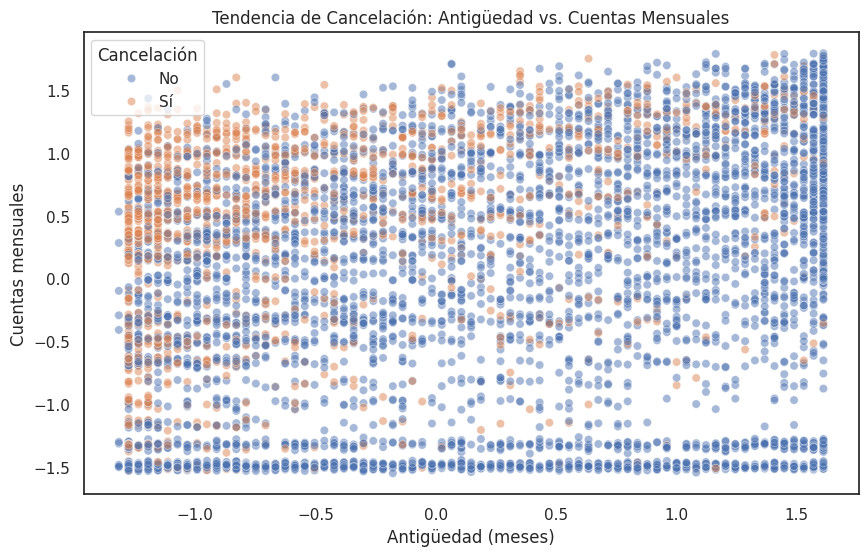

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Antigüedad (meses)', y='Cuentas mensuales',
                hue=X['Cancelación (churn)'].map({0: 'No', 1: 'Sí'}), data=X, alpha=0.5)
plt.title('Tendencia de Cancelación: Antigüedad vs. Cuentas Mensuales')
plt.xlabel('Antigüedad (meses)')
plt.ylabel('Cuentas mensuales')
plt.legend(title='Cancelación')

plt.show()

# Modelado predictivo

A continuación, se crearán dos modelos, para realizar el objetivo del presente notebook: predecir en qué circunstancias se producirán la mayor parte de las cancelaciones.

# ⚠ ADVERTENCIA ⚠

Cada vez que se ejecuten los bloques de código de abajo, los resultados serán distintos a los de las ejecuciones anteriores. Tenga sumo cuidado al estudiar los datos.

## Separación de datos

Primeramente se deberán crear cuatro conjuntos de datos, dos de entrenamiento y otros dos de prueba; y de cada par de conjuntos, uno de los dos son las cancelaciones como variables resultado.

In [ ]:
# Separamos la variable objetivo (Cancelación) del DataFrame
y = X['Cancelación (churn)']
X.drop(columns = ['Cancelación (churn)'], inplace = True)

# Creamos los conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verificamos los tamaños
print(f"Registros totales: {len(X)}")
print(f"Registros para entrenar: {len(X_train)}")
print(f"Registros para probar: {len(X_test)}")

Registros totales: 7043
Registros para entrenar: 5634
Registros para probar: 1409


## Creación de modelos

Crearemos los modelos: uno de los dos usará regresión logística, y el otro usará Random Forest.

*   **Regresión Logística**: Es un algoritmo de clasificación que modela la probabilidad de que una instancia dada pertenezca a una clase específica. Se utiliza para predecir un resultado binario (como 'sí' o 'no', 'churn' o 'no churn') basándose en una o más variables predictoras. A pesar de su nombre, es un modelo de clasificación, no de regresión, que estima la probabilidad mediante la función logística.

*   **Random Forest**: Es un algoritmo de aprendizaje supervisado que construye múltiples árboles de decisión durante el entrenamiento y genera la salida que es la clase (o la media de la predicción) de los árboles individuales. Es conocido por su precisión y por su capacidad para manejar un gran número de características sin sobreajuste. Es un algoritmo robusto y versátil utilizado tanto para clasificación como para regresión.

Usaremos para ambos modelos `class_weight='balanced'` por el desbalance del 26.5% que encontramos (el porcentaje de clientes que cancelaron).

In [ ]:
# Creamos el Modelo A (Regresión Logística)
model_log = LogisticRegression(class_weight='balanced', random_state=42)

# Creamos el Modelo B (Random Forest)
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Entrenamos ambos
model_log.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## Evaluación de los modelos

En dichas matrices, las intersecciones entre los ceros y entre los unos reflejan los verdaderos negativos y los verdaderos positivos respectivamente, mientras que si la realidad es 0 y la predicción 1, se tienen los falsos positivos, y al revés (si la realidad es 1 y la predicción 0), se tienen los falsos negativos, el rincón peligroso (clientes que se fueron pero el modelo predijo que se quedaban). La exactitud es la alicuota de verdaderos positivos y negativos que predijo el modelo (sobre el total de datos).

Con respecto a los informes de clasificación, en las filas de 0 y 1, la precisión indica cuántas de las predicciones positivas (1) o negativas (0) que hizo el modelo, fueron correctas. El recall, o sensibilidad, indica, de todos los clientes que cancelaron o no cancelaron (según la cifra), cuántos identificó el modelo. La puntiación F1, o F1-score, se calcula como 2 * (Precisión * Recall) / (Precisión + Recall). Consiste en el promedio armónico entre la precisión y el recall. Es especialmente útil en clases desbalanceadas y cuando se busca equilibrio entre la precisión y el recall, y cuando es alto, indica que el modelo tiene buenas precisión y recall. El soporte (support) no es más que el porcentaje total de clientes que cancelaron, o no, en el conjunto de datos de prueba.

En nuestro caso, nos interesa especialmente, en las matrices, la fila de `Realidad = 1`, ya que es la que le interesa a Telecom X, y en el informe, sólo nos interesan la fila de unos (por el mismo motivo) y las columnas de precisión y sensibilidad (porque no haremos uso alguno del puntaje F1 de momento, y tampoco nos interesa el total de clientes que (realmente)cancelaron); es preferible predecir falsamente que muchos clientes iban a irse, que equivocarse y pensar que muchos clientes abandónicos iban a quedarse, y lo segundo es lo que quiere evitar la empresa. En las matrices, podemos ver que son mucho mayores los verdaderos positivos del modelo de regresión logística que los del modelo de Random Forest, así como mucho menores los falsos negativos; esto supone una ventaja significativa por parte del modelo de regresión logística, dado que refleja un mayor cumplimiento del objetivo pautado; de hecho, las cifras para el modelo de regresión logística son relativamente pobres.

Ahora procedemos a la lectura del informe (alicuota de exactitud y fila de unos). El modelo de Random forest puede figurar como el más exacto, pero porque detectó una mayor cantidad de verdaderos negativos (justo lo que a la empresa no le interesa de forma primordial en el momento); se trata de una trampa. El modelo de Random forest también parece evidenciar una mayor precisión, pero porque, del conjunto de clientes que cada modelo predijo que cancelaban, la cantidad de clientes que realmente cancelaron fue mayor para el modelo de Random forest; se podría decir que dicho modelo es más exacto cuando levanta la mano y menos propenso a falsas alarmas. Aquí viene otro de los datos que más nos interesa: la sensibilidad, que mucho mayor para el modelo de regresión logística, mientras que el de Random forest deja escapar una cantidad preocupante (quizás alrededor de la mitad o superior) de los que cancelaron.

Por lo tanto, el modelo de regresión logística es el más propicio para predecir qué clientes van a cancelar.

--- Evaluación: Regresión Logística ---
Exactitud: 0.75

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



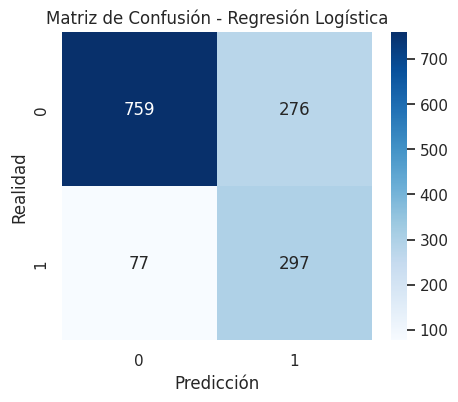

In [ ]:
def evaluar_modelo(modelo, nombre, X_test, y_test):
    # Predicciones
    y_pred = modelo.predict(X_test)

    print(f"--- Evaluación: {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_test, y_pred):.2f}")
    print("\nInforme de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Realidad')
    plt.xlabel('Predicción')
    plt.show()

evaluar_modelo(model_log, "Regresión Logística", X_test, y_test)

--- Evaluación: Random Forest ---
Exactitud: 0.78

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



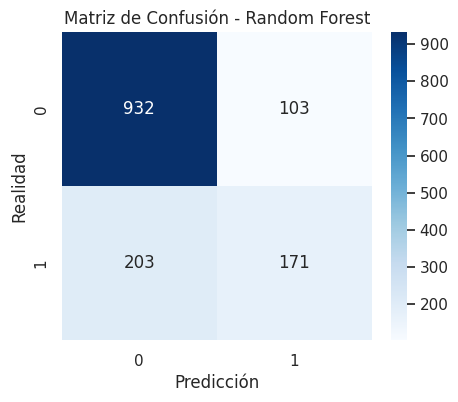

In [ ]:
evaluar_modelo(model_rf, "Random Forest", X_test, y_test)

# Análisis de la importancia de las variables

Los siguientes diagramas de barras detallan las variables más "importantes" para cada modelo, es decir, las que más toma en cuenta cada modelo para predecir que "va a irse".

Para el modelo de regresión logística, se tienen en cuenta los coeficientes de las variables, que muestran su contribución a la predicción de cancelación. Aquí, cada variable tiene un peso ($\beta$).

*   Valor Positivo: Aumenta la probabilidad de que el cliente cancele.
*   Valor Negativo: Disminuye la probabilidad (genera lealtad).

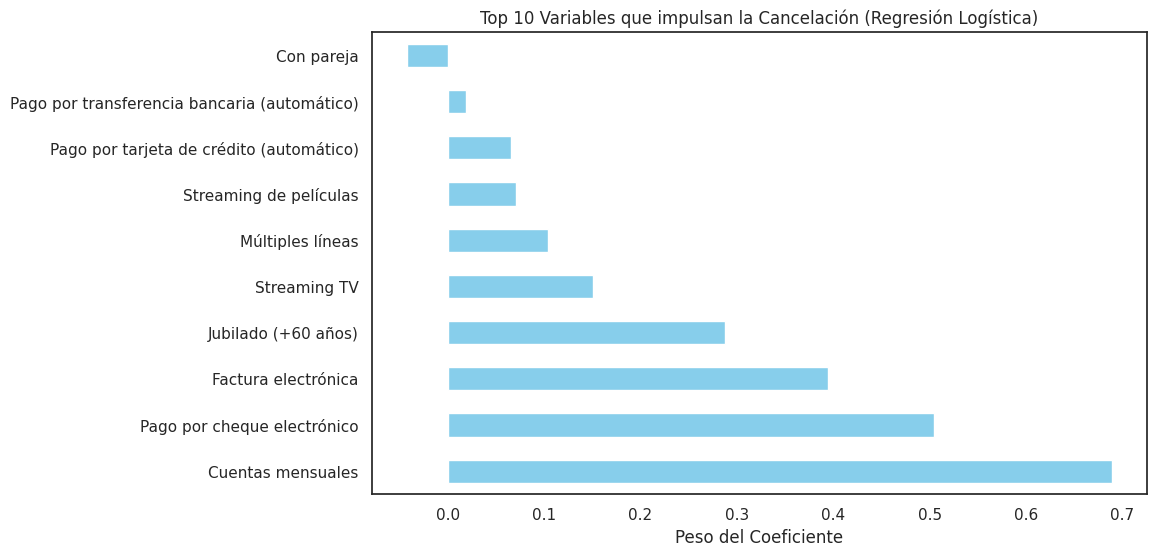

In [ ]:
# Extraemos los coeficientes
importancia_log = pd.Series(model_log.coef_[0], index=X_train.columns).sort_values(ascending=False)

# Graficamos los 10 más importantes
plt.figure(figsize=(10, 6))
importancia_log.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables que impulsan la Cancelación (Regresión Logística)')
plt.xlabel('Peso del Coeficiente')
plt.show()

Para el modelo de Random Forest, se tiene en cuenta la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles. Esto implica que aquí no hay valores negativos: el valor de la importancia de cada variable va de 0 a 1.

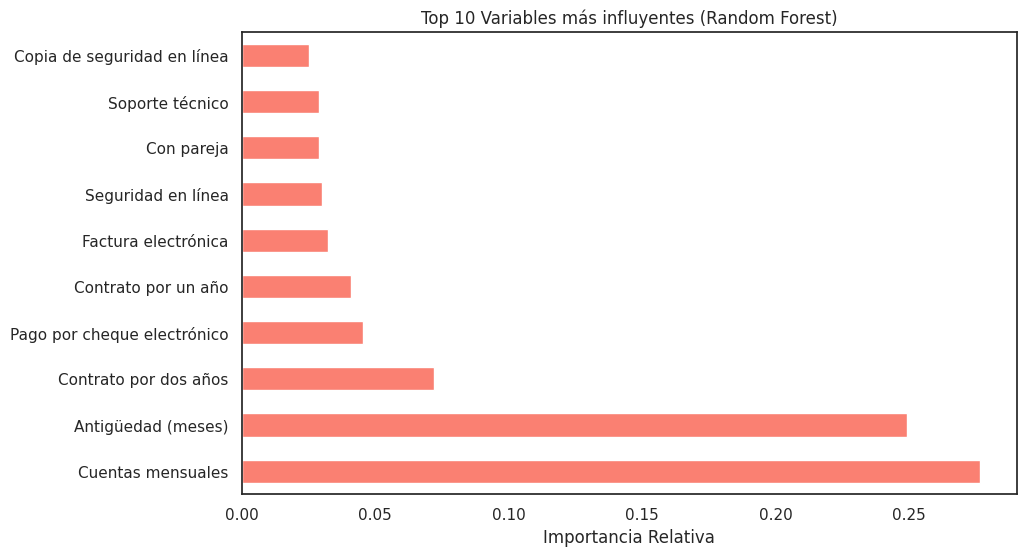

In [ ]:
# Extraemos la importancia
importancia_rf = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))
importancia_rf.head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.show()

# Conclusiones

## Sobre las variables importantes para los modelos

Respecto al funcionamiento de los modelos, ambos consideraron a las cuentas mensuales como la variable más importante; esto refleja la gran importancia de este parámetro a la hora de estimar si un cliente va a irse, así como el contar con fibra óptica y las cuotas totales (las variables eliminadas antes de crear los modelos porque se correlacionaban con los cobros mensuales).

El modelo de regresión logística consideró como las tres más importantes los cobros mensuales, el método de pago del cheque electrónico, y la factura electrónica. En base a esto, se puede deducir que estas son las variables que hacen al modelo decidir qué clientes son los que más propensamente se van a ir. Es muy probable que el alto costo de las tarifas de Telecom X, o quizás (puede que también) el alto costo y/o el funcionamiento de la fibra óptica (correlacionada con los costos mensuales), provoque que este factor sea tan importante. De nuevo, el método de pago por cheque electrónico también aparece como factor relevante para que clientes abandonen el servicio, al igual que en el challenge anterior; quizás los cheques electrónicos no funcionan bien, tardan en procesar las transferencias de dinero, o acaso lo hacen mal o tienen otra falla severa. Y aparece el uso o no factura electrónica como factor de interés; quizás los procesadores de facturas electrónicas de Telecom X generen un descontento con los clientes, y puede que el motivo sea el mismo mencionado anteriormente sobre el pago por cheque electrónico.

El modelo de Random Forest consideró como las tres variables más importantes los cobros mensuales, la antigüedad en meses del cliente en el servicio, y el contrato por dos años. El modelo prioriza el tiempo y el dinero: dado que son las variables que más clientes abandónicos aglutinan, el algoritmo considera que saber cuánto paga el cliente y hace cuánto tiempo estuvo en el sistema es el 80% (aproximadamente) de la respuesta. Y también parece tener en cuenta la situación de los contratos: el tener un contrato a tan largo plazo como es a dos años parece influir en la decisión de una marcada parte de los clientes en quedarse; y según los resultados del análisis en el challenge anterior, se vio que la mayor parte de los clientes que cancelaron el servicio de Telecom X tenían contratos de mes a mes, por lo que aprovecharon el hecho de tener un compromiso volátil para cancelar inmediatamente.

## Sobre los modelos

Claramente, el modelo de regresión logística es el que mejor predice si un cliente puede cancelar o no; tiene una tasa baja de falsos negativos en comparación con Random Forest, que dejó pasar a alrededor o más del 50%. Por lo tanto, es el algoritmo ideal en este contexto, incluso si emite un gran volumen de falsas alarmas. En el mundo de las redes y telecomunicaciones, es muchísimo más barato enviarle una promoción o un descuento a alguien que no se iba a ir (una falsa alarma), que perder para siempre a un cliente que pagaba una factura alta porque el modelo no lo detectó a tiempo.

## Conclusión general

Considero que los costos (mensuales, diarios y totales) y el contar con fibra óptica son los factores que más atención merecen, ya que los clientes que más pagan y con fibra óptica son los que más se van; y dicho factor aumenta aún más si dichos clientes son novatos (0 o pocos meses de antigüedad). El método de pago por cheque electrónico también merece atención, ya que podría estar generando un disgusto hacia la clientela.

Propongo que se revise masivamente la infraestructura digital (incluyendo los servidores y los sistemas de pago y procesamiento de facturas) y el servicio de fibra de Telecom X, dado que podría estar funcionando mal; que se ajusten los precios de los servicios o se ofrezcan ofertas o descuentos a los clientes novatos que opten por servicios premium; y que, en caso de que surgiese de nuevo el problema de la fuga masiva de clientes y se intentase estudiar y predecir los motivos, se utilice la regresión logística, antes que Random Forest, debido a su superior confiabilidad. Quizás tendría más sentido cobrar un poco menos a los clientes nuevos (como mecanismo para retenerlos) que a los veteranos que ya llevan tiempo gozando constantemente del servicio.